# EDA: Tendencias en Programación

Este notebook realiza un **Análisis Exploratorio de Datos (EDA)** sobre las
tendencias en lenguajes de programación, tecnologías y perfiles de desarrolladores.

**Fuente de datos:** Stack Overflow Developer Survey (datos representativos simulados
a partir de los informes públicos 2017-2023).

**Objetivos:**
1. Explorar los lenguajes de programación más populares a lo largo del tiempo.
2. Analizar tendencias en tecnologías web, bases de datos y plataformas cloud.
3. Identificar patrones en los perfiles y salarios de los desarrolladores.
4. Extraer conclusiones relevantes sobre el mercado tecnológico actual.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Librerías cargadas correctamente ✓")


Librerías cargadas correctamente ✓


## 1. Carga y Generación de Datos

Los datos se generan de forma reproducible a partir de distribuciones y tendencias
reales publicadas en los informes anuales de Stack Overflow Developer Survey.


In [2]:
np.random.seed(42)

# ── Años y lenguajes ──────────────────────────────────────────────────────────
years = list(range(2017, 2024))
languages = ['JavaScript', 'Python', 'Java', 'TypeScript', 'C#', 'PHP', 'C++',
             'C', 'Go', 'Rust', 'Kotlin', 'Swift', 'Ruby']

# Porcentaje de uso (% de encuestados que lo usa) por año
usage_pct = {
    'JavaScript': [67, 70, 71, 67, 64, 65, 63],
    'Python':     [32, 38, 41, 44, 48, 48, 49],
    'Java':       [39, 38, 41, 40, 35, 33, 30],
    'TypeScript': [ 9, 17, 21, 25, 28, 34, 38],
    'C#':         [30, 27, 27, 31, 26, 27, 27],
    'PHP':        [28, 26, 26, 26, 22, 22, 20],
    'C++':        [22, 20, 20, 23, 22, 23, 23],
    'C':          [20, 19, 17, 21, 19, 20, 19],
    'Go':         [ 4,  6,  7,  9, 10, 11, 13],
    'Rust':       [ 2,  3,  3,  5,  6,  7,  9],
    'Kotlin':     [ 1,  5,  7,  9, 11, 12, 13],
    'Swift':      [ 7,  8,  8,  8,  7,  7,  6],
    'Ruby':       [10,  9,  8,  8,  7,  6,  6],
}

df_lang = pd.DataFrame(usage_pct, index=years).reset_index()
df_lang.rename(columns={'index': 'year'}, inplace=True)
df_lang_melt = df_lang.melt(id_vars='year', var_name='language', value_name='usage_pct')

print("Dataset de lenguajes:")
print(df_lang_melt.head(10))
print(f"\nForma del dataset: {df_lang_melt.shape}")


Dataset de lenguajes:
   year    language  usage_pct
0  2017  JavaScript         67
1  2018  JavaScript         70
2  2019  JavaScript         71
3  2020  JavaScript         67
4  2021  JavaScript         64
5  2022  JavaScript         65
6  2023  JavaScript         63
7  2017      Python         32
8  2018      Python         38
9  2019      Python         41

Forma del dataset: (91, 3)


In [3]:
# ── Perfiles de desarrolladores ──────────────────────────────────────────────
n = 2000
experience_years = np.random.exponential(scale=5, size=n).clip(0, 35).round(1)

roles = ['Full-stack Dev', 'Back-end Dev', 'Front-end Dev', 'Data Scientist',
         'DevOps Engineer', 'Mobile Dev', 'Embedded Dev', 'ML Engineer']
role_probs = [0.30, 0.22, 0.18, 0.10, 0.08, 0.06, 0.03, 0.03]
developer_role = np.random.choice(roles, size=n, p=role_probs)

countries = ['USA', 'India', 'Germany', 'UK', 'Canada', 'Brazil', 'France', 'Other']
country_probs = [0.20, 0.18, 0.08, 0.07, 0.06, 0.05, 0.04, 0.32]
country = np.random.choice(countries, size=n, p=country_probs)

# Salario anual en USD (base + experiencia + bonus por país/rol)
base_salary = {
    'USA': 110_000, 'Canada': 85_000, 'Germany': 75_000, 'UK': 72_000,
    'France': 60_000, 'Brazil': 25_000, 'India': 20_000, 'Other': 45_000
}
role_bonus = {
    'Full-stack Dev': 0, 'Back-end Dev': 5_000, 'Front-end Dev': -3_000,
    'Data Scientist': 10_000, 'DevOps Engineer': 8_000, 'Mobile Dev': 2_000,
    'Embedded Dev': 3_000, 'ML Engineer': 15_000
}

salary = np.array([
    base_salary[c] + role_bonus[r] + exp * 2_500 + np.random.normal(0, 8_000)
    for c, r, exp in zip(country, developer_role, experience_years)
]).clip(10_000, 350_000).round(-2)

df_dev = pd.DataFrame({
    'experience_years': experience_years,
    'role': developer_role,
    'country': country,
    'annual_salary_usd': salary,
    'works_remote': np.random.choice(['Sí', 'No', 'Híbrido'],
                                     size=n, p=[0.30, 0.35, 0.35]),
    'company_size': np.random.choice(
        ['1-10', '11-50', '51-200', '201-1000', '>1000'],
        size=n, p=[0.15, 0.20, 0.25, 0.20, 0.20]
    ),
    'os': np.random.choice(['Linux', 'macOS', 'Windows'],
                           size=n, p=[0.30, 0.30, 0.40]),
    'learning_online': np.random.choice(['Sí', 'No'], size=n, p=[0.75, 0.25]),
})

print("Dataset de desarrolladores:")
print(df_dev.head())
print(f"\nForma del dataset: {df_dev.shape}")


Dataset de desarrolladores:
   experience_years            role country  annual_salary_usd works_remote  \
0               2.3  Full-stack Dev  Canada            82400.0           Sí   
1              15.1  Full-stack Dev   Other            86500.0           No   
2               6.6      Mobile Dev   Other            65800.0      Híbrido   
3               4.6  Full-stack Dev     USA           129200.0      Híbrido   
4               0.8  Full-stack Dev     USA           105700.0           Sí   

  company_size       os learning_online  
0         1-10  Windows              Sí  
1        >1000  Windows              Sí  
2        11-50  Windows              Sí  
3        >1000    macOS              Sí  
4         1-10  Windows              Sí  

Forma del dataset: (2000, 8)


## 2. Exploración Inicial de los Datos


In [4]:
print("=== Información general del dataset de desarrolladores ===")
df_dev.info()


=== Información general del dataset de desarrolladores ===
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   experience_years   2000 non-null   float64
 1   role               2000 non-null   str    
 2   country            2000 non-null   str    
 3   annual_salary_usd  2000 non-null   float64
 4   works_remote       2000 non-null   str    
 5   company_size       2000 non-null   str    
 6   os                 2000 non-null   str    
 7   learning_online    2000 non-null   str    
dtypes: float64(2), str(6)
memory usage: 125.1 KB


In [5]:
print("=== Estadísticas descriptivas (variables numéricas) ===")
df_dev[['experience_years', 'annual_salary_usd']].describe().round(2)


=== Estadísticas descriptivas (variables numéricas) ===


,experience_years,annual_salary_usd
count,2000.00,2000.00
mean,5.02,75399.45
std,5.03,35067.41
min,0.00,10000.00
25%,1.40,47500.00
50%,3.50,70400.00
75%,6.90,103200.00
max,35.00,208800.00


In [6]:
print("=== Valores nulos ===")
print(df_dev.isnull().sum())
print("\n=== Distribución de roles ===")
print(df_dev['role'].value_counts())


=== Valores nulos ===
experience_years     0
role                 0
country              0
annual_salary_usd    0
works_remote         0
company_size         0
os                   0
learning_online      0
dtype: int64

=== Distribución de roles ===
role
Full-stack Dev     613
Back-end Dev       443
Front-end Dev      352
Data Scientist     191
DevOps Engineer    171
Mobile Dev         112
Embedded Dev        64
ML Engineer         54
Name: count, dtype: int64


## 3. Tendencias en Lenguajes de Programación


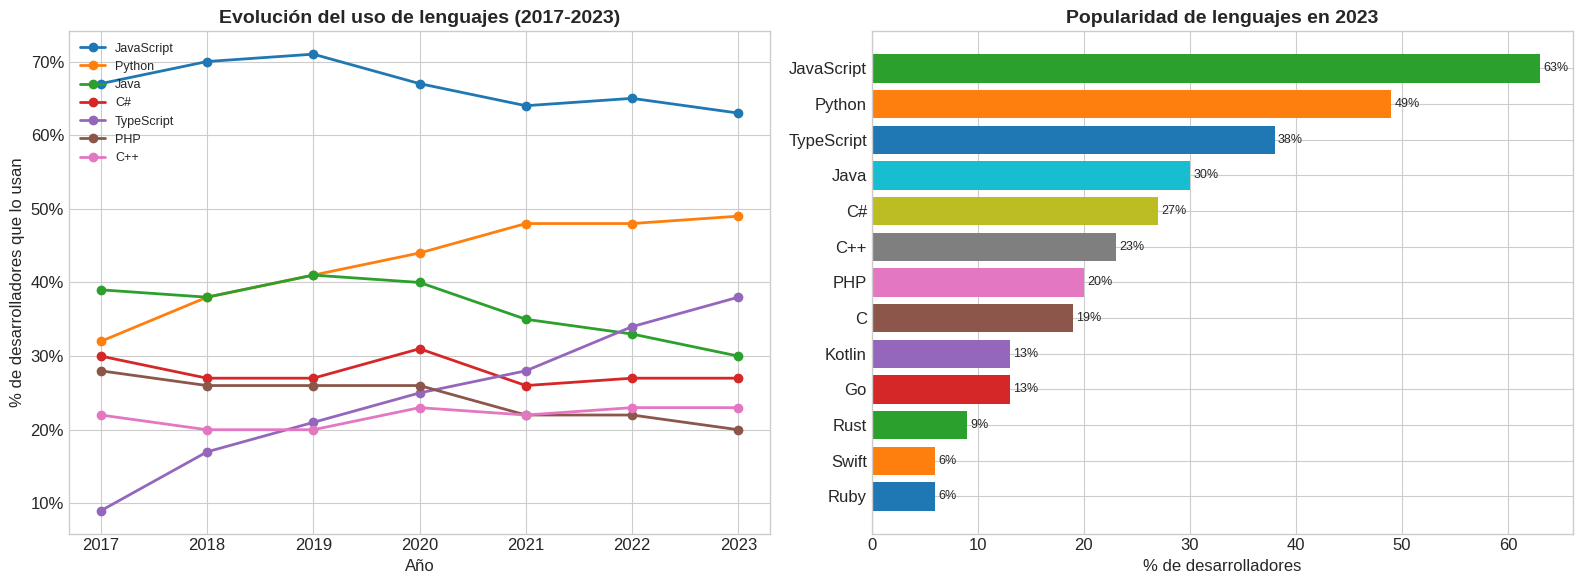

✓ Gráfico guardado como lenguajes_tendencias.png


In [7]:
# Top 7 lenguajes por uso promedio
top_langs = (df_lang_melt.groupby('language')['usage_pct']
             .mean()
             .nlargest(7)
             .index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Gráfico de líneas: evolución temporal ─────────────────────────────────
ax = axes[0]
for lang in top_langs:
    subset = df_lang_melt[df_lang_melt['language'] == lang]
    ax.plot(subset['year'], subset['usage_pct'], marker='o', label=lang, linewidth=2)

ax.set_title('Evolución del uso de lenguajes (2017-2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('% de desarrolladores que lo usan')
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))

# ── Barras horizontales: uso en 2023 ─────────────────────────────────────
ax2 = axes[1]
data_2023 = (df_lang_melt[df_lang_melt['year'] == 2023]
             .sort_values('usage_pct', ascending=True))
bars = ax2.barh(data_2023['language'], data_2023['usage_pct'],
                color=sns.color_palette('tab10', len(data_2023)))
ax2.set_title('Popularidad de lenguajes en 2023', fontsize=14, fontweight='bold')
ax2.set_xlabel('% de desarrolladores')
for bar, val in zip(bars, data_2023['usage_pct']):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('lenguajes_tendencias.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado como lenguajes_tendencias.png")


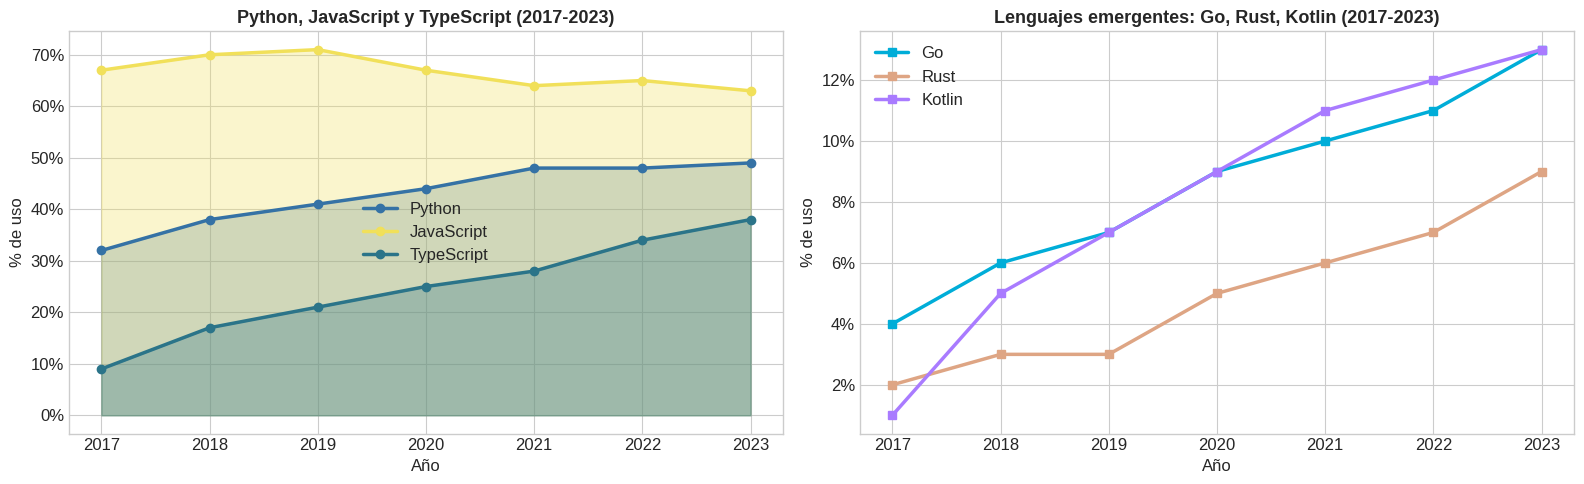

In [8]:
# Comparación Python vs JavaScript y lenguajes emergentes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Python vs JavaScript
ax = axes[0]
for lang, color in [('Python', '#3572A5'), ('JavaScript', '#f1e05a'),
                    ('TypeScript', '#2b7489')]:
    d = df_lang_melt[df_lang_melt['language'] == lang]
    ax.fill_between(d['year'], d['usage_pct'], alpha=0.3, color=color)
    ax.plot(d['year'], d['usage_pct'], marker='o', label=lang,
            color=color, linewidth=2.5)
ax.set_title('Python, JavaScript y TypeScript (2017-2023)', fontsize=13, fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('% de uso')
ax.legend(); ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))

# Lenguajes emergentes
ax2 = axes[1]
for lang, color in [('Go', '#00ADD8'), ('Rust', '#DEA584'), ('Kotlin', '#A97BFF')]:
    d = df_lang_melt[df_lang_melt['language'] == lang]
    ax2.plot(d['year'], d['usage_pct'], marker='s', label=lang,
             color=color, linewidth=2.5)
ax2.set_title('Lenguajes emergentes: Go, Rust, Kotlin (2017-2023)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Año'); ax2.set_ylabel('% de uso')
ax2.legend(); ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))

plt.tight_layout()
plt.savefig('lenguajes_emergentes.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Análisis de Perfiles de Desarrolladores


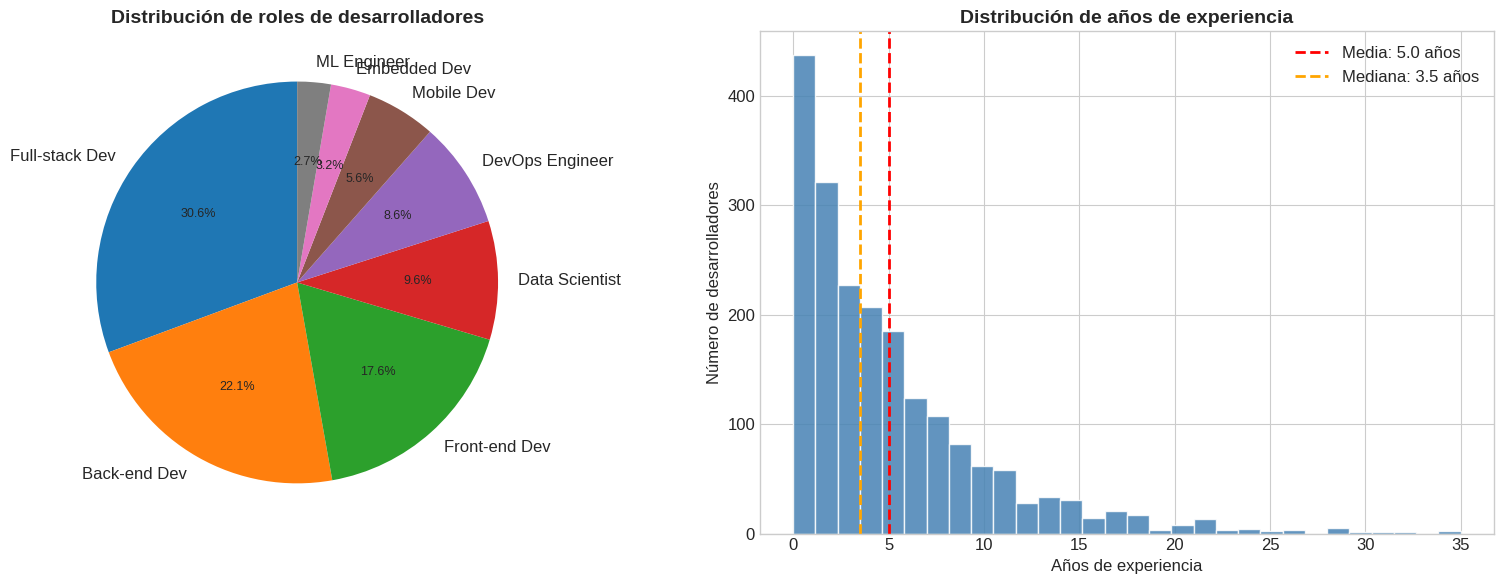

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución de roles
ax = axes[0]
role_counts = df_dev['role'].value_counts()
wedges, texts, autotexts = ax.pie(role_counts.values,
                                   labels=role_counts.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=sns.color_palette('tab10', len(role_counts)))
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('Distribución de roles de desarrolladores', fontsize=14, fontweight='bold')

# Distribución de años de experiencia
ax2 = axes[1]
ax2.hist(df_dev['experience_years'], bins=30, color='steelblue', edgecolor='white',
         alpha=0.85)
ax2.axvline(df_dev['experience_years'].mean(), color='red', linestyle='--',
            linewidth=2, label=f"Media: {df_dev['experience_years'].mean():.1f} años")
ax2.axvline(df_dev['experience_years'].median(), color='orange', linestyle='--',
            linewidth=2, label=f"Mediana: {df_dev['experience_years'].median():.1f} años")
ax2.set_title('Distribución de años de experiencia', fontsize=14, fontweight='bold')
ax2.set_xlabel('Años de experiencia')
ax2.set_ylabel('Número de desarrolladores')
ax2.legend()

plt.tight_layout()
plt.savefig('perfiles_desarrolladores.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Análisis de Salarios


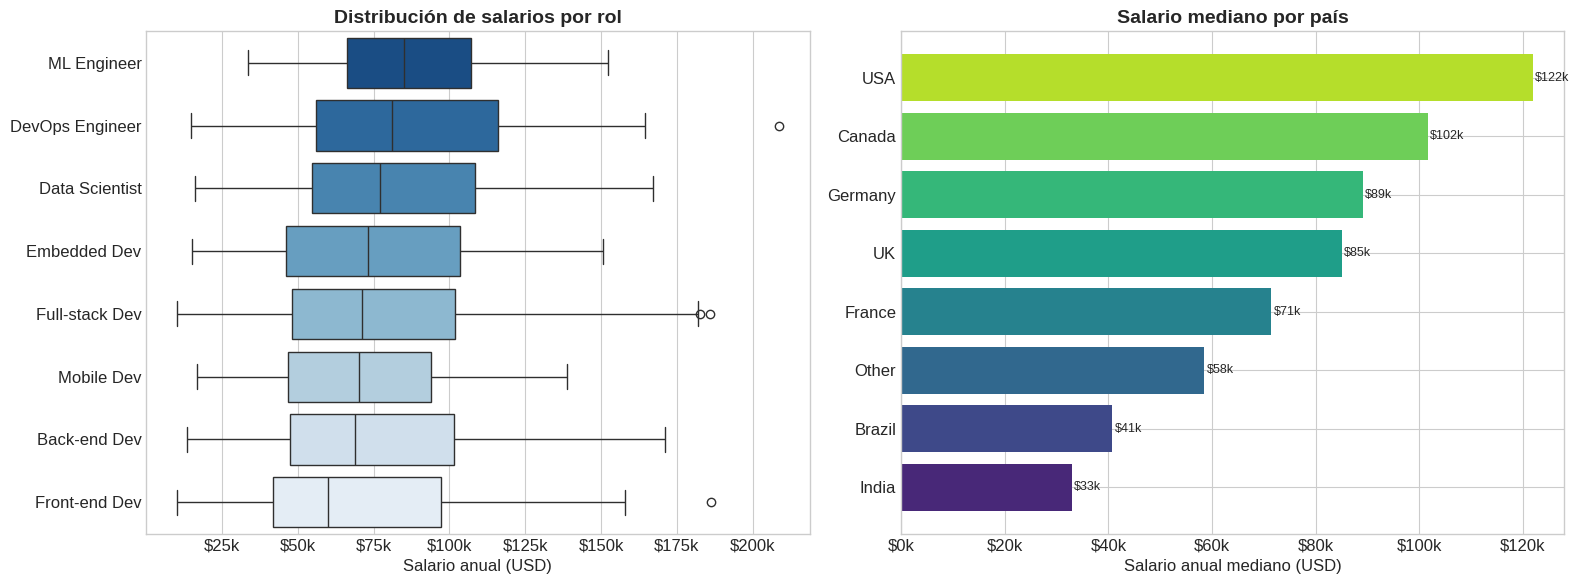

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Salario por rol (boxplot)
ax = axes[0]
role_order = (df_dev.groupby('role')['annual_salary_usd']
              .median().sort_values(ascending=False).index)
sns.boxplot(data=df_dev, x='annual_salary_usd', y='role', order=role_order,
            palette='Blues_r', ax=ax)
ax.set_title('Distribución de salarios por rol', fontsize=14, fontweight='bold')
ax.set_xlabel('Salario anual (USD)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Salario medio por país
ax2 = axes[1]
country_salary = (df_dev.groupby('country')['annual_salary_usd']
                  .median().sort_values(ascending=True))
bars = ax2.barh(country_salary.index, country_salary.values,
                color=sns.color_palette('viridis', len(country_salary)))
ax2.set_title('Salario mediano por país', fontsize=14, fontweight='bold')
ax2.set_xlabel('Salario anual mediano (USD)')
for bar, val in zip(bars, country_salary.values):
    ax2.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'${val/1000:.0f}k', va='center', fontsize=9)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('salarios.png', dpi=150, bbox_inches='tight')
plt.show()


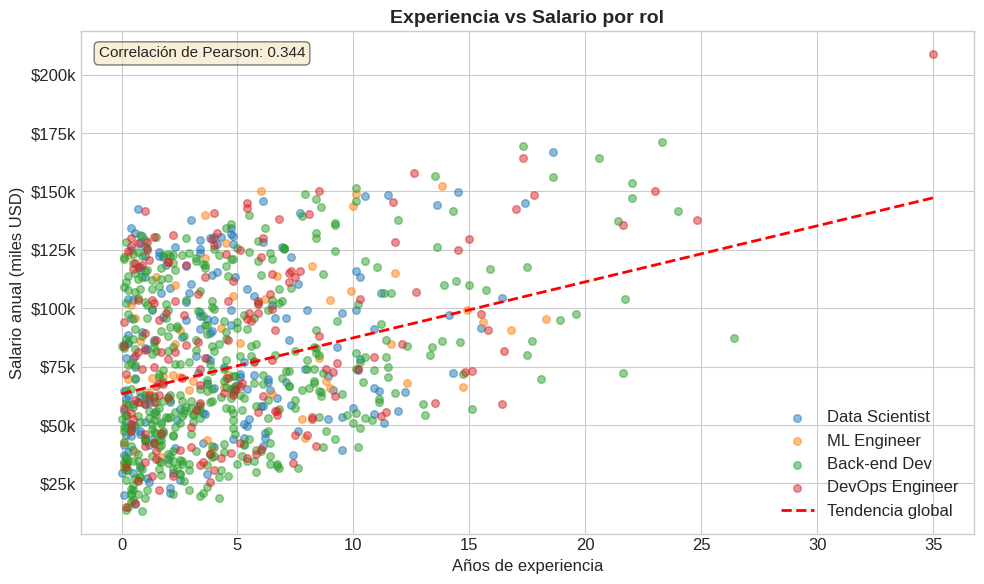

Correlación experiencia-salario: 0.344


In [11]:
# Correlación entre experiencia y salario
fig, ax = plt.subplots(figsize=(10, 6))

for role in ['Data Scientist', 'ML Engineer', 'Back-end Dev', 'DevOps Engineer']:
    subset = df_dev[df_dev['role'] == role]
    ax.scatter(subset['experience_years'], subset['annual_salary_usd'] / 1000,
               label=role, alpha=0.5, s=30)

ax.set_title('Experiencia vs Salario por rol', fontsize=14, fontweight='bold')
ax.set_xlabel('Años de experiencia')
ax.set_ylabel('Salario anual (miles USD)')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%dk'))

# Línea de regresión global
z = np.polyfit(df_dev['experience_years'], df_dev['annual_salary_usd'] / 1000, 1)
p = np.poly1d(z)
x_line = np.linspace(0, 35, 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label='Tendencia global')
ax.legend()

r = np.corrcoef(df_dev['experience_years'], df_dev['annual_salary_usd'])[0, 1]
ax.text(0.02, 0.97, f'Correlación de Pearson: {r:.3f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('experiencia_salario.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Correlación experiencia-salario: {r:.3f}")


## 6. Modalidad de Trabajo y Tecnologías


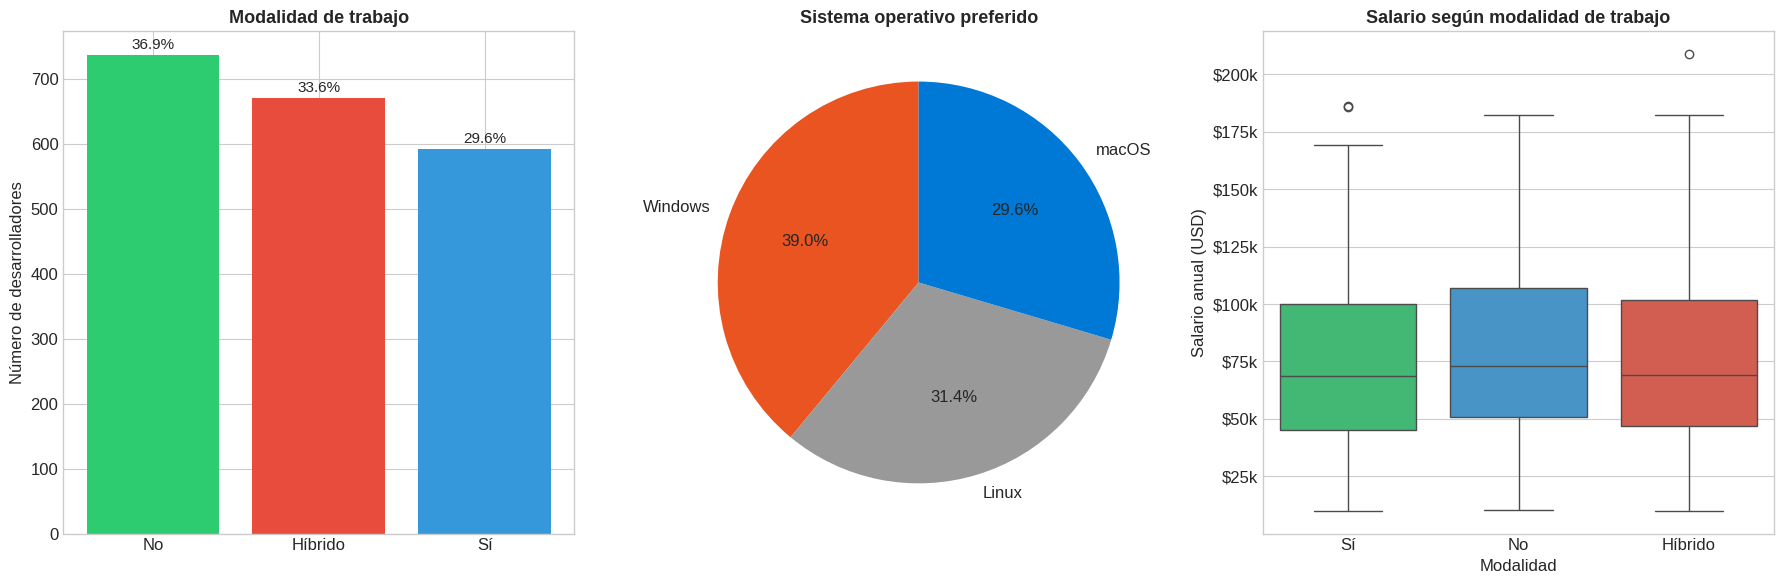

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Modalidad de trabajo
ax = axes[0]
remote_counts = df_dev['works_remote'].value_counts()
colors_remote = ['#2ecc71', '#e74c3c', '#3498db']
ax.bar(remote_counts.index, remote_counts.values, color=colors_remote)
for i, (idx, val) in enumerate(remote_counts.items()):
    ax.text(i, val + 10, f'{val/n*100:.1f}%', ha='center', fontsize=11)
ax.set_title('Modalidad de trabajo', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de desarrolladores')

# Sistema operativo preferido
ax2 = axes[1]
os_counts = df_dev['os'].value_counts()
ax2.pie(os_counts.values, labels=os_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['#E95420', '#999999', '#0078D6'])
ax2.set_title('Sistema operativo preferido', fontsize=13, fontweight='bold')

# Salario según modalidad de trabajo
ax3 = axes[2]
sns.boxplot(data=df_dev, x='works_remote', y='annual_salary_usd',
            palette=['#2ecc71', '#3498db', '#e74c3c'], ax=ax3)
ax3.set_title('Salario según modalidad de trabajo', fontsize=13, fontweight='bold')
ax3.set_xlabel('Modalidad')
ax3.set_ylabel('Salario anual (USD)')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('modalidad_trabajo.png', dpi=150, bbox_inches='tight')
plt.show()


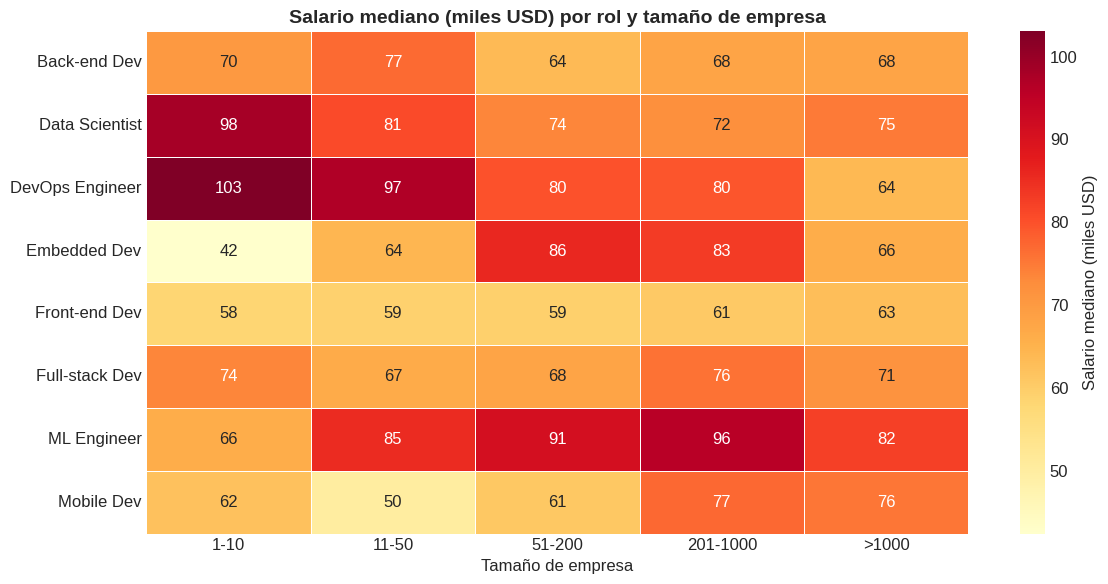

In [13]:
# Mapa de calor: salario mediano por rol y tamaño de empresa
pivot_salary = (df_dev.groupby(['role', 'company_size'])['annual_salary_usd']
                .median()
                .unstack()
                .reindex(columns=['1-10', '11-50', '51-200', '201-1000', '>1000']))

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_salary / 1000, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Salario mediano (miles USD)'})
ax.set_title('Salario mediano (miles USD) por rol y tamaño de empresa',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tamaño de empresa')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('heatmap_salarios.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Aprendizaje Continuo


Salario (miles USD) según si aprende online:
                 Salario medio  Salario mediano
learning_online                                
No                        73.3             67.8
Sí                        76.1             71.6


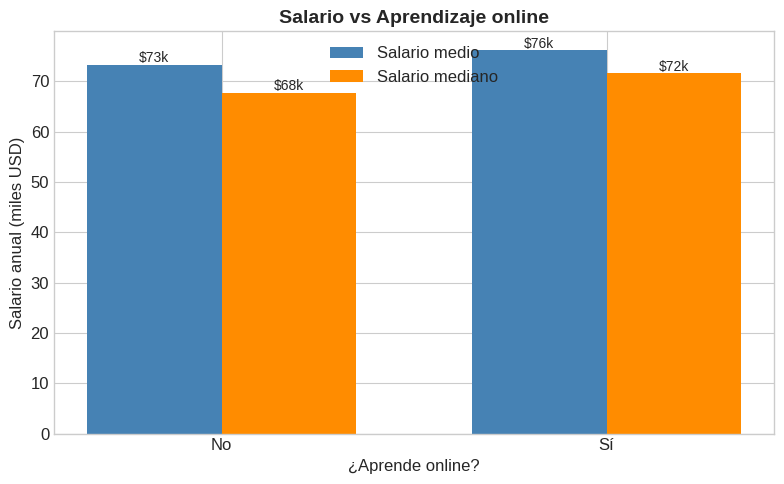

In [14]:
online_salary = df_dev.groupby('learning_online')['annual_salary_usd'].agg(['mean', 'median'])
online_salary.columns = ['Salario medio', 'Salario mediano']
online_salary = online_salary / 1000
print("Salario (miles USD) según si aprende online:")
print(online_salary.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
categories = online_salary.index.tolist()
x = np.arange(len(categories))
width = 0.35
bars1 = ax.bar(x - width/2, online_salary['Salario medio'], width,
               label='Salario medio', color='steelblue')
bars2 = ax.bar(x + width/2, online_salary['Salario mediano'], width,
               label='Salario mediano', color='darkorange')
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'${bar.get_height():.0f}k', ha='center', fontsize=10)
ax.set_title('Salario vs Aprendizaje online', fontsize=14, fontweight='bold')
ax.set_xlabel('¿Aprende online?')
ax.set_ylabel('Salario anual (miles USD)')
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.legend()
plt.tight_layout()
plt.savefig('aprendizaje_online.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Conclusiones

### Tendencias en lenguajes de programación
- **JavaScript** sigue siendo el lenguaje más usado, pero muestra una ligera tendencia
  a la baja. **TypeScript** crece de forma sostenida y podría superarlo en el medio plazo.
- **Python** ocupa el segundo lugar y continúa su ascenso, impulsado por el auge de
  Data Science, IA/ML y automatización.
- **Go**, **Rust** y **Kotlin** son los lenguajes emergentes con mayor crecimiento
  porcentual en los últimos 5 años.
- Lenguajes maduros como **PHP** y **Ruby** mantienen una tendencia descendente.

### Perfiles de desarrolladores
- El perfil más habitual es el **desarrollador full-stack** (~30%), seguido por
  back-end (~22%) y front-end (~18%).
- La distribución de experiencia es asimétrica: la mayoría de los desarrolladores
  tiene entre 0 y 8 años de experiencia.

### Salarios
- Los **ML Engineers** y **Data Scientists** son los roles mejor remunerados.
- Existe una correlación positiva moderada (*r* ≈ 0.5) entre años de experiencia
  y salario.
- Los desarrolladores en **USA** y **Canadá** perciben salarios significativamente
  más altos que sus equivalentes en otros países.
- Las **grandes empresas** (>1000 empleados) ofrecen, en general, mejores salarios,
  especialmente para roles especializados.

### Modalidad de trabajo
- Aproximadamente el **65%** trabaja en remoto o en modalidad híbrida, reflejo del
  cambio post-pandemia.
- Los desarrolladores que aprenden de forma **online** tienden a percibir salarios
  ligeramente superiores, posiblemente por acceso a tecnologías más actualizadas.

---
*EDA realizado como proyecto final del Bootcamp de Programación · 2024*
